# Glass Type Classification with Machine Learning

  Hey there and welcome to this kernel! My name is Walid. I'm a data science newbie and this is my first Kaggle notebook. I have been putting a lot of effort recently to start my journey in data science. I benefited a lot from the notebooks of other awesome kagglers and I hope you benefit this notebook and learn new stuff from it.

<hr >

# Contents

## 1) Prepare Problem

 * Load libraries

 * Load and explore the shape of the dataset

## 2) Summarize Data

* Descriptive statistics

* Data visualization

## 3) Prepare Data

* Data Cleaning

* Split-out validation dataset

*  Data transformation  

## 4) Evaluate Algorithms

* Dimensionality reduction

* Compare Algorithms

## 5) Improve Accuracy

* Algorithm Tuning

## 6) Diagnose the performance of the best algorithms

* Diagnose overfitting by plotting the learning and validation curves
* Further tuning

## 7) Finalize Model

* Create standalone model on entire training dataset

* Predictions on test dataset

<hr />

## 1. Prepare Problem

### Loading the libraries 

Let us first begin by loading the libraries that we'll use in the notebook

In [35]:
import numpy as np  # linear algebra
import pandas as pd  # read and wrangle dataframes
import matplotlib.pyplot as plt # visualization
import seaborn as sns # statistical visualizations and aesthetics
from sklearn.base import TransformerMixin # To create new classes for transformations
from sklearn.preprocessing import (FunctionTransformer, StandardScaler) # preprocessing 
from sklearn.decomposition import PCA # dimensionality reduction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy.stats import boxcox # data transform
from sklearn.metrics import classification_report
from sklearn.model_selection import (train_test_split, KFold , StratifiedKFold, 
                                     cross_val_score, GridSearchCV, 
                                     learning_curve, validation_curve) # model selection modules
from sklearn.pipeline import Pipeline # streaming pipelines
from sklearn.base import BaseEstimator, TransformerMixin # To create a box-cox transformation class
from collections import Counter
import warnings
# load models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import (XGBClassifier, plot_importance)
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from time import time

%matplotlib inline 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

### Loading and exploring the shape of the dataset

In [36]:
df = pd.read_csv(r'C:\Users\Dell\Desktop\data\covid-19 data\input_bcell.csv')
test = pd.read_csv(r'C:\Users\Dell\Desktop\data\covid-19 data\input_sars.csv')

print(df.shape)

(14387, 14)


The dataset consists of 14907 observations

In [37]:
df.head(15)

,parent_protein_id,protein_seq,start_position,end_position,peptide_seq,chou_fasman,emini,kolaskar_tongaonkar,parker,isoelectric_point,aromaticity,hydrophobicity,stability,target
0,A2T3T0,MDVLYSLSKTLKDARDKIVEGTLYSNVSDLIQQFNQMIITMNGNEF...,161,165,SASFT,1.016,0.703,1.018,2.22,5.810364,0.103275,-0.143829,40.273300,1
1,F0V2I4,MTIHKVAINGFGRIGRLLFRNLLSSQGVQVVAVNDVVDIKVLTHLL...,251,255,LCLKI,0.770,0.179,1.199,-3.86,6.210876,0.065476,-0.036905,24.998512,1
2,O75508,MVATCLQVVGFVTSFVGWIGVIVTTSTNDWVVTCGYTIPTCRKLDE...,145,149,AHRET,0.852,3.427,0.960,4.28,8.223938,0.091787,0.879227,27.863333,1
3,O84462,MTNSISGYQPTVTTSTSSTTSASGASGSLGASSVSTTANATVTQTA...,152,156,SNYDD,1.410,2.548,0.936,6.32,4.237976,0.044776,-0.521393,30.765373,1
4,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,85,89,DGTYR,1.214,1.908,0.937,4.64,6.867493,0.103846,-0.578846,21.684615,1
5,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,155,159,GLQKV,0.928,0.547,1.090,0.90,6.867493,0.103846,-0.578846,21.684615,1
6,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,22,26,IAKGE,0.888,0.633,0.974,2.66,6.867493,0.103846,-0.578846,21.684615,1
7,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,253,257,RQIKA,0.814,1.252,1.007,2.00,6.867493,0.103846,-0.578846,21.684615,1
8,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,218,222,SSEQV,1.016,1.042,1.055,4.62,6.867493,0.103846,-0.578846,21.684615,1
9,P01012,MGSIGAASMEFCFDVFKELKVHHANENIFYCPIAIMSALAMVYLGA...,261,265,NFEKL,0.900,1.301,0.980,0.42,5.193909,0.085492,-0.001036,37.108575,1


In [38]:
df.dtypes

parent_protein_id       object
protein_seq             object
start_position           int64
end_position             int64
peptide_seq             object
chou_fasman            float64
emini                  float64
kolaskar_tongaonkar    float64
parker                 float64
isoelectric_point      float64
aromaticity            float64
hydrophobicity         float64
stability              float64
target                   int64
dtype: object

let check the cols with object type

In [39]:
peptide_seq_train = df['peptide_seq'].value_counts().sort_values()
peptide_seq_test = test['peptide_seq'].value_counts().sort_values()

protein_seq_train = df['protein_seq'].value_counts().sort_values()
protein_seq_test = test['protein_seq'].value_counts().sort_values()


parent_protein_id_train = df['parent_protein_id'].value_counts().sort_values()
parent_protein_id_test = test['parent_protein_id'].value_counts().sort_values()

num_same_peptide = 0
num_protein = 0
num_parent_protein = 0

for value in peptide_seq_train:
    if value in peptide_seq_test:
        num_protein += 1
        
for value in protein_seq_train:
    if value in protein_seq_test:
        num_same_peptide += 1
        
for value in parent_protein_id_train:
    if value in parent_protein_id_test:
        num_parent_protein += 1
        
print("num of same peptide seq : ", num_same_peptide)

print("num of same protein seq : ", num_same_peptide)

print("num of same parent protein id : ", num_parent_protein)

num of same peptide seq :  0
num of same protein seq :  0
num of same parent protein id :  0


we find that we can't encode this cat cols cs they don't share the same value

they are like ids for the instances

In [40]:
#drop the cat cols 
df.drop(['peptide_seq', 'protein_seq', 'parent_protein_id'], axis=1, inplace=True)
test.drop(['peptide_seq', 'protein_seq', 'parent_protein_id'], axis=1, inplace=True)

features = df.columns[:-1].tolist()

## 2. Summarize data

### Descriptive statistics

Let's first summarize the distribution of the numerical 
variables. 

In [41]:
df.describe()

,start_position,end_position,chou_fasman,emini,kolaskar_tongaonkar,parker,isoelectric_point,aromaticity,hydrophobicity,stability,target
count,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000,14387.000000
mean,297.675818,308.085077,0.994706,1.059788,1.021188,1.767137,7.067472,0.075727,-0.406097,43.703902,0.271217
std,353.741450,353.733297,0.124772,1.621931,0.053804,1.968985,1.888708,0.025767,0.394618,16.682362,0.444603
min,1.000000,6.000000,0.534000,0.000000,0.838000,-9.029000,3.686096,0.000000,-1.971171,5.448936,0.000000
25%,84.000000,95.000000,0.911000,0.248000,0.986000,0.600000,5.621033,0.060606,-0.606215,31.614529,0.000000
50%,191.000000,200.000000,0.990000,0.556000,1.020000,1.793000,6.499573,0.074534,-0.330540,42.287268,0.000000
75%,382.000000,393.000000,1.074000,1.209000,1.055000,3.009500,8.676575,0.091312,-0.189591,49.101172,1.000000
max,3079.000000,3086.000000,1.546000,27.189000,1.255000,9.120000,12.232727,0.182254,1.267089,137.046667,1.000000


The features are not on the same scale. For example start_position has a mean of 308.845173 while aromaticity has a mean value of 0.077143. Features should be on the same scale for algorithms such as logistic regression (gradient descent) to converge smoothly. Let's go ahead and check the distribution of the data types.

In [42]:
df['target'].value_counts() * 100 / len(df)

0    72.878293
1    27.121707
Name: target, dtype: float64

The dataset is pretty unbalanced. The instances of class 0  constitute more than 72 % while class 1 with only 27 %.

###  Data Visualization

#### * **Univariate plots**

Let's go ahead an look at the distribution of the different features of this dataset.

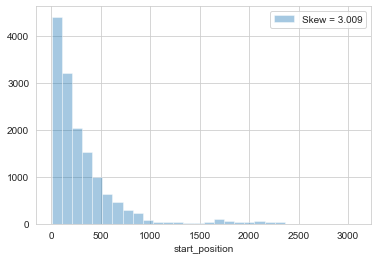

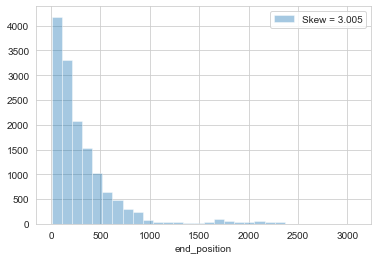

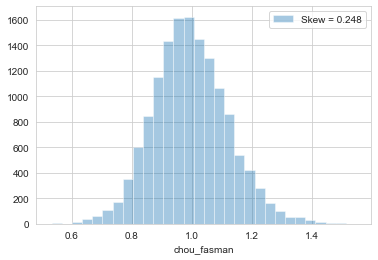

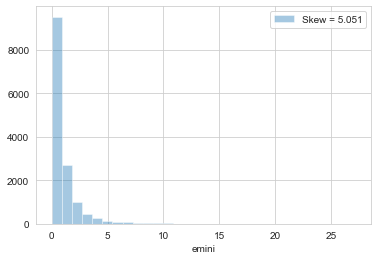

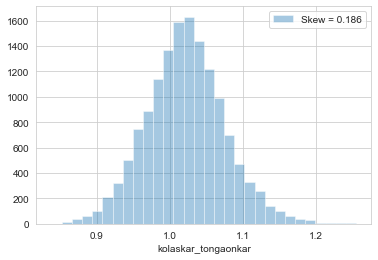

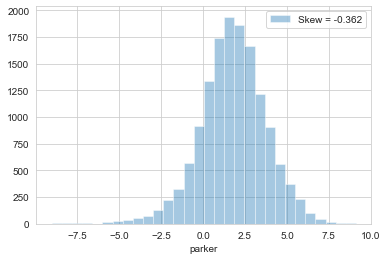

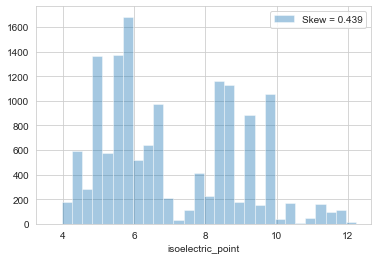

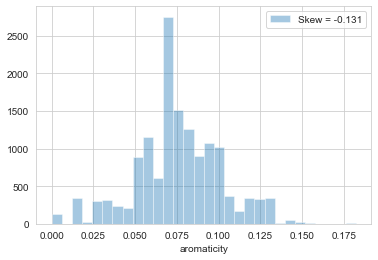

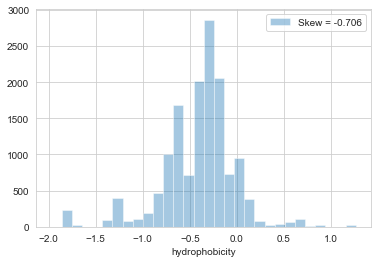

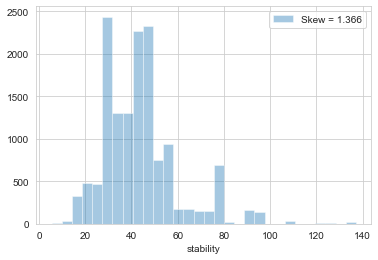

In [43]:
for feat in features:
    skew = df[feat].skew()
    sns.distplot(df[feat], kde= False, label='Skew = %.3f' %(skew), bins=30)
    plt.legend(loc='best')
    plt.show()

There is some features is no normally distributed. The features emini, end_position, stability and start_position exhibit the highest skew coefficients. Moreover, the distribution of stability and others seem to contain outliers. Let's identify the indices of the observations containing outliers using [Turkey's method](http://datapigtechnologies.com/blog/index.php/highlighting-outliers-in-your-data-with-the-tukey-method/).

In [44]:
# Detect observations with more than one outlier

def outlier_hunt(df):
    """
    Takes a dataframe df of features and returns a list of the indices
    corresponding to the observations containing more than 2 outliers. 
    """
    outlier_indices = []
    
    # iterate over features(columns)
    for col in df.columns.tolist():
        # 1st quartile (25%)
        Q1 = np.percentile(df[col], 25)
        
        # 3rd quartile (75%)
        Q3 = np.percentile(df[col],75)
        
        # Interquartile rrange (IQR)
        IQR = Q3 - Q1
        
        # outlier step
        outlier_step = 1.5 * IQR
        
        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index
        
        # append the found outlier indices for col to the list of outlier indices 
        outlier_indices.extend(outlier_list_col)
        
    # select observations containing more than 2 outliers
    outlier_indices = Counter(outlier_indices)        
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > 2 )
    
    return multiple_outliers   

print('The dataset contains %d observations with more than 2 outliers' %(len(outlier_hunt(df[features]))))   

The dataset contains 357 observations with more than 2 outliers


Aha! there exists some 457 observations with multiple outliers.  These  could harm the efficiency of our learning algorithms. We'll make sure to get rid of these in the next sections.

Let's examine the boxplots for the several distributions.

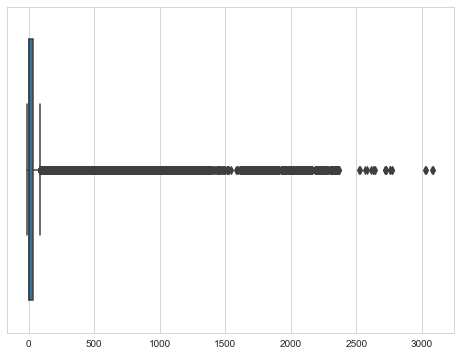

In [45]:
plt.figure(figsize=(8,6))
sns.boxplot(df[features])
plt.show()

#### * **Multivariate plots**

Let's now proceed by drawing a pairplot to visually examine the correlation between the features.

In [46]:
# plt.figure(figsize=(8,8))
# sns.pairplot(df[features],palette='coolwarm')
# plt.show()

Let's go ahead and examine a heatmap of the correlations.

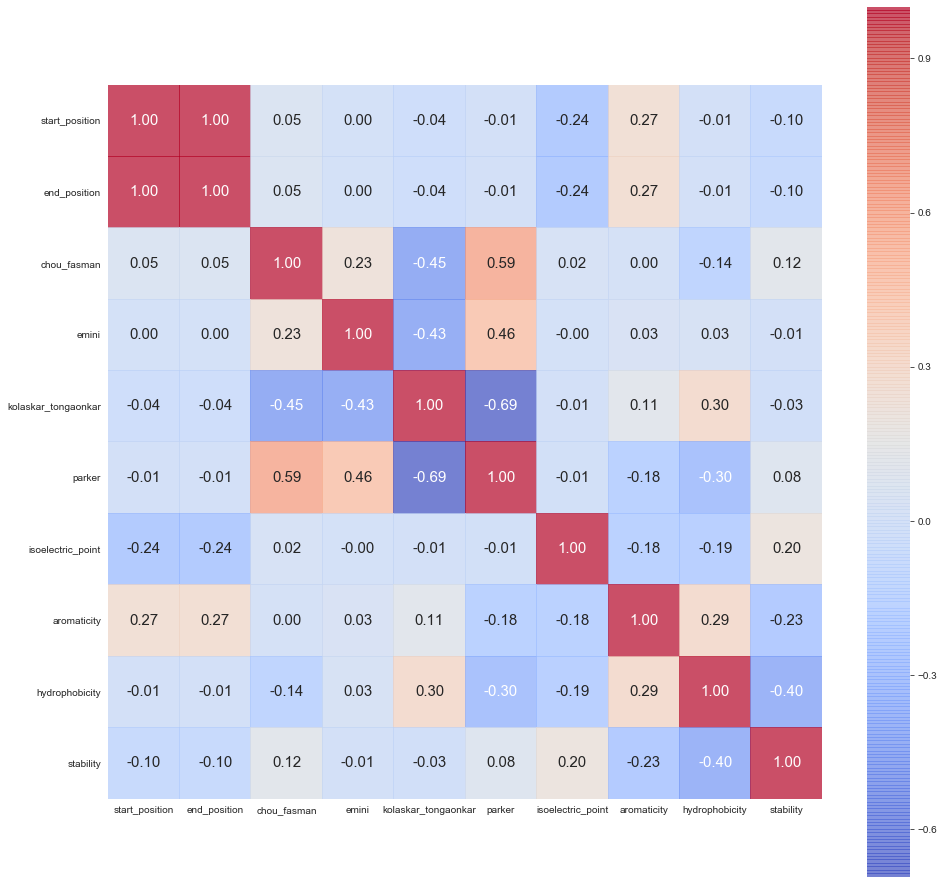

In [47]:
corr = df[features].corr()
plt.figure(figsize=(16,16))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= features, yticklabels= features, alpha = 0.7,   cmap= 'coolwarm')
plt.show()

There seems to be a strong positive correlation between start_position and end_position. This could be a hint to perform Principal component analysis in order to decorrelate some of the input features.

std of length :  2.8746462762165925


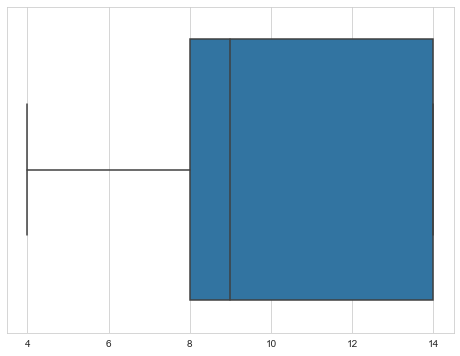

In [48]:
length_df = df['end_position'] - df['start_position']
length_test = test['end_position'] - test['start_position']


df.drop(['end_position'], axis=1, inplace=True)
test.drop(['end_position'], axis=1, inplace=True)

df['length'] = length_df
test['length'] = length_test

features = df.drop('target', axis=1).columns.tolist()

print('std of length : ',np.std(length_df))

plt.figure(figsize=(8,6))
sns.boxplot(length_df)
plt.show()

## 3. Prepare data

### - Data cleaning

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14387 entries, 0 to 14386
Data columns (total 11 columns):
start_position         14387 non-null int64
chou_fasman            14387 non-null float64
emini                  14387 non-null float64
kolaskar_tongaonkar    14387 non-null float64
parker                 14387 non-null float64
isoelectric_point      14387 non-null float64
aromaticity            14387 non-null float64
hydrophobicity         14387 non-null float64
stability              14387 non-null float64
target                 14387 non-null int64
length                 14387 non-null int64
dtypes: float64(8), int64(3)
memory usage: 1.2 MB


This dataset is clean; there aren't any missing values in it.

### ### - Hunting and removing multiple outliers

Let's remove the observations containing multiple outliers with the function we created in the previous section.

In [50]:
outlier_indices = outlier_hunt(df[features])
df = df.drop(outlier_indices).reset_index(drop=True)
print(df.shape)

(14109, 11)


Removing observations with multiple outliers (more than 2) leaves us with 14577 observations to learn from. Let's now see how our distributions look like.

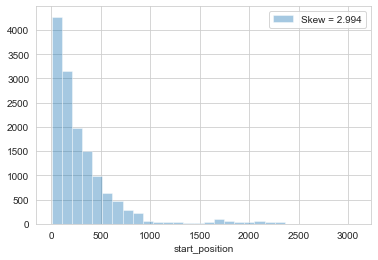

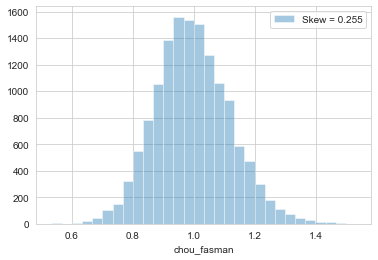

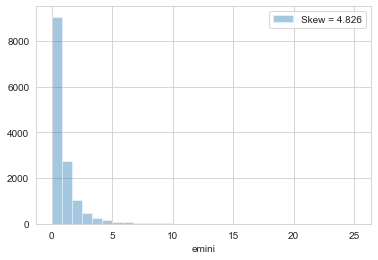

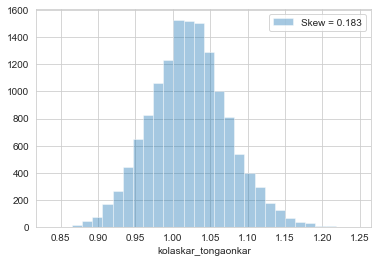

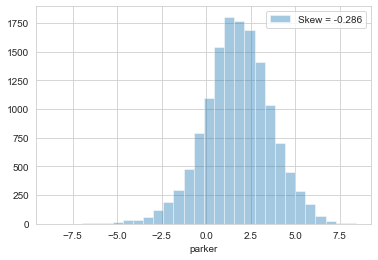

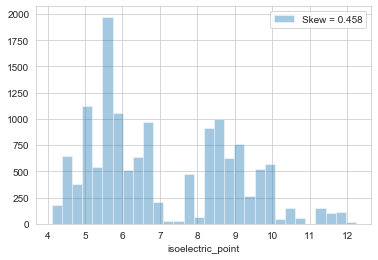

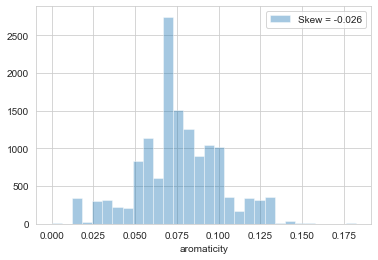

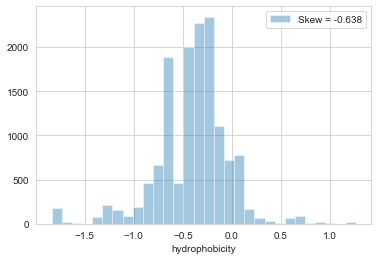

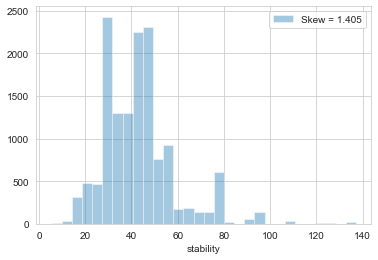

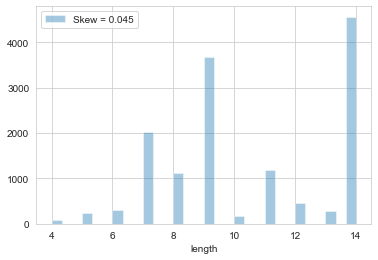

In [51]:
for feat in features:
    skew = df[feat].skew()
    sns.distplot(df[feat], kde=False, label='Skew = %.3f' %(skew), bins=30)
    plt.legend(loc='best')
    plt.show()

In [52]:
df['target'].value_counts()

0    10252
1     3857
Name: target, dtype: int64

Let's now plot a distribution of the classes.

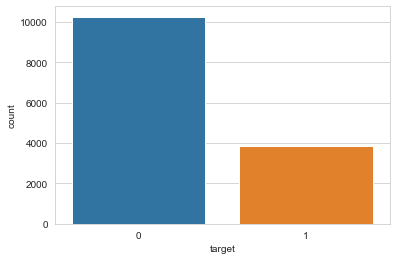

In [53]:
sns.countplot(df['target'])
plt.show()

### - Split-out validation dataset

In [54]:
# Define X as features and y as lablels
X = df[features] 
y = df['target'] 
# set a seed and a test size for splitting the dataset 
seed = 7
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size , random_state = seed)

### - Data transformation  

Let's examine if a Box-Cox transform can contribute to the normalization of some features. It should be emphasized that all transformations should only be done on the training set to avoid data snooping. Otherwise the test error estimation will be biased.

In [55]:
features_boxcox = []

for feature in features:
    bc_transformed, _ = boxcox(df[feature]+10)  # shift by 1 to avoid computing log of negative values
    features_boxcox.append(bc_transformed)

features_boxcox = np.column_stack(features_boxcox)
df_bc = pd.DataFrame(data=features_boxcox, columns=features)
df_bc['target'] = df['target']

In [56]:
X = df_bc[features] 
y = df_bc['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size , random_state = seed)

In [57]:
df_bc.describe()

,start_position,chou_fasman,emini,kolaskar_tongaonkar,parker,isoelectric_point,aromaticity,hydrophobicity,stability,length,target
count,14109.000000,1.410900e+04,1.410900e+04,1.410900e+04,14109.000000,14109.000000,14109.000000,14109.000000,14109.000000,14109.000000,14109.000000
mean,6.863027,1.623479e-01,1.150578e-01,8.721278e-02,25.682800,0.534010,3132.704614,1037.698970,3.138778,6.876840,0.273372
std,1.737484,4.279653e-09,6.385075e-11,1.190796e-14,6.137948,0.000543,31.640710,142.762911,0.178387,0.614607,0.445706
min,2.694237,1.623479e-01,1.150578e-01,8.721278e-02,0.336763,0.532934,3036.501327,569.187034,2.337404,5.386932,0.000000
25%,5.702936,1.623479e-01,1.150578e-01,8.721278e-02,21.743572,0.533603,3114.970703,952.266210,3.012996,6.358609,0.000000
50%,6.910560,1.623479e-01,1.150578e-01,8.721278e-02,25.530831,0.533932,3130.706544,1056.790914,3.157710,6.583721,0.000000
75%,8.063986,1.623479e-01,1.150578e-01,8.721278e-02,29.502715,0.534511,3151.656159,1112.517291,3.233757,7.627792,1.000000
max,12.078401,1.623479e-01,1.150578e-01,8.721278e-02,50.330294,0.535148,3269.594660,1840.981273,3.766201,7.627792,1.000000


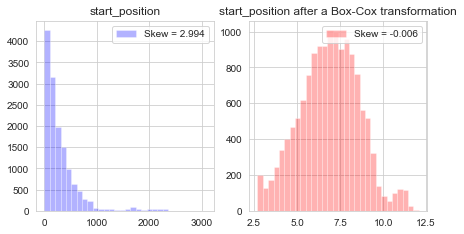

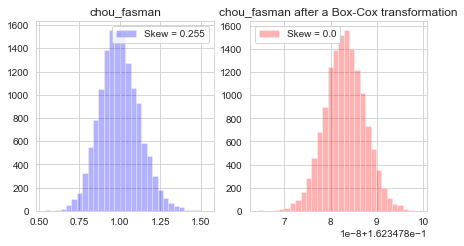

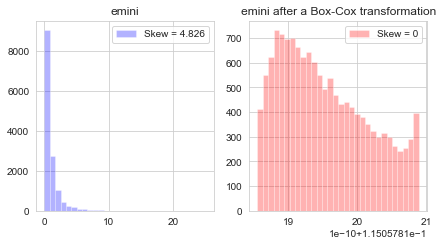

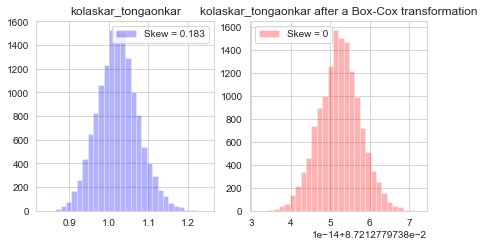

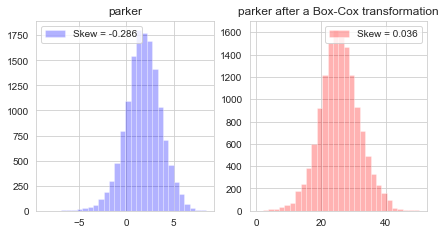

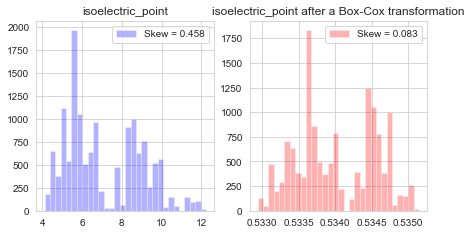

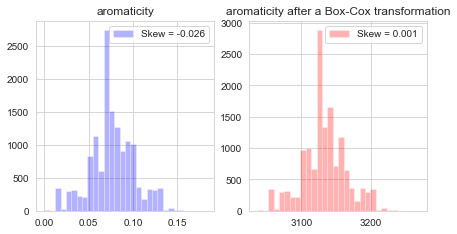

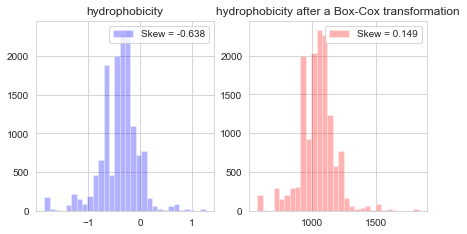

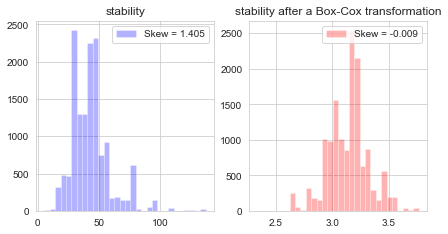

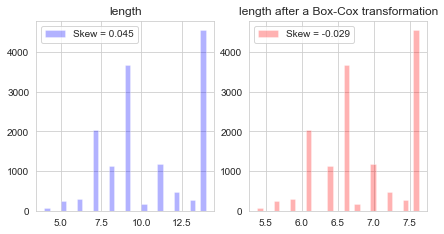

In [58]:
for feature in features:
    fig, ax = plt.subplots(1,2,figsize=(7,3.5))    
    ax[0].hist(df[feature], color='blue', bins=30, alpha=0.3, label='Skew = %s' %(str(round(df[feature].skew(),3))) )
    ax[0].set_title(str(feature))   
    ax[0].legend(loc=0)
    ax[1].hist(df_bc[feature], color='red', bins=30, alpha=0.3, label='Skew = %s' %(str(round(df_bc[feature].skew(),3))) )
    ax[1].set_title(str(feature)+' after a Box-Cox transformation')
    ax[1].legend(loc=0)
    plt.show()

In [59]:
# check if skew is closer to zero after a box-cox transform
for feature in features:
    delta = np.abs( df_bc[feature].skew() / df[feature].skew() )
    if delta < 1.0 :
        print('Feature %20s is less skewed after a Box-Cox transform' %(feature))
    else:
        print('Feature %20s is more skewed after a Box-Cox transform'  %(feature))

Feature       start_position is less skewed after a Box-Cox transform
Feature          chou_fasman is less skewed after a Box-Cox transform
Feature                emini is less skewed after a Box-Cox transform
Feature  kolaskar_tongaonkar is less skewed after a Box-Cox transform
Feature               parker is less skewed after a Box-Cox transform
Feature    isoelectric_point is less skewed after a Box-Cox transform
Feature          aromaticity is less skewed after a Box-Cox transform
Feature       hydrophobicity is less skewed after a Box-Cox transform
Feature            stability is less skewed after a Box-Cox transform
Feature               length is less skewed after a Box-Cox transform


The Box-Cox transform seems to do a good job in reducing the skews of the different distributions of features.  However, it does not lead to the normalization of the feature distributions. Trial and error showed that it doesn't lead to an improvement of the performance of the used algorithms.  Next, let's explore dimensionality reduction techniques.

## 4. Evaluate Algorithms

### - Dimensionality reduction

#### **XGBoost**

Elapsed time to train XGBoost  0.438 seconds


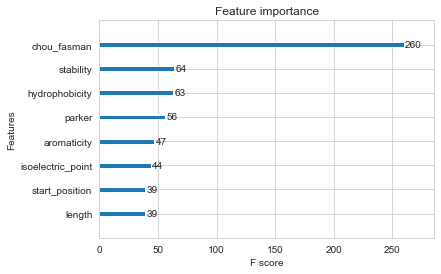

In [60]:
model_importances = XGBClassifier()
start = time()
model_importances.fit(X_train, y_train)
print('Elapsed time to train XGBoost  %.3f seconds' %(time()-start))
plot_importance(model_importances)
plt.show()

It appears that no main features dominate the importance in the XGBoost modeling of the problem. 

#### **PCA**

Let's go ahead and perform a PCA on the features to decorrelate the ones that are linearly dependent and then let's plot the cumulative explained variance.

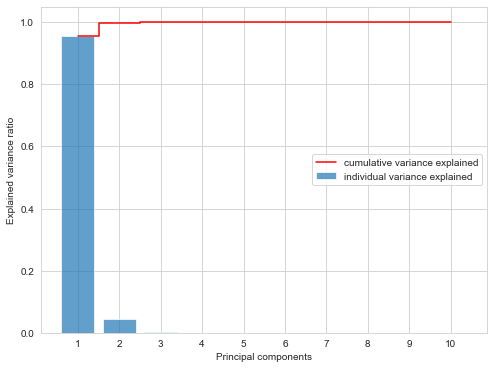

PC1 Cumulative variance:  95.43213792014575
PC2 Cumulative variance:  99.82161151174253
PC3 Cumulative variance:  99.98494040822938
PC4 Cumulative variance:  99.99815415013772
PC5 Cumulative variance:  99.99986861891047
PC6 Cumulative variance:  99.99999999877929
PC7 Cumulative variance:  100.0
PC8 Cumulative variance:  100.0
PC9 Cumulative variance:  100.0
PC10 Cumulative variance:  100.0


In [61]:
pca = PCA(random_state = seed)
pca.fit(X_train)
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)
plt.figure(figsize=(8,6))
plt.bar(range(1,len(cum_var_exp)+1), var_exp, align= 'center', label= 'individual variance explained', \
       alpha = 0.7)
plt.step(range(1,len(cum_var_exp)+1), cum_var_exp, where = 'mid' , label= 'cumulative variance explained', \
        color= 'red')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.xticks(np.arange(1,len(var_exp)+1,1))
plt.legend(loc='center right')
plt.show()

# Cumulative variance explained
for i, sum in enumerate(cum_var_exp):
    print("PC" + str(i+1), "Cumulative variance: ",cum_var_exp[i]*100)

It appears that about 99.7 % of the variance can be explained with the first 1 principal components. However feeding the PCA features to the learning algorithms did not contribute to a better performance. This might be due to the non-linearites that PCA is not able to capture.

### - Compare Algorithms

Now it's time to compare the performance of different machine learning algorithms. We'll use 10-folds cross-validation to assess the performance of each model with the metric being the classification accuracy. Pipelines encompassing Standarization and PCA are used in order to avoid data leakage. Standarization is not performed for tree-based methods.

SVC: 44.285521 (+/- 3.583798) performed in 16.901459 seconds
KNN: 57.170814 (+/- 3.675268) performed in 0.432059 seconds
RF: 75.605879 (+/- 2.656231) performed in 10.952340 seconds
Ada: 59.298525 (+/- 2.116769) performed in 6.478344 seconds
ET: 74.672662 (+/- 2.529757) performed in 6.645971 seconds
GB: 60.121000 (+/- 3.198607) performed in 2.970793 seconds
LR: 11.487604 (+/- 2.171720) performed in 0.299450 seconds


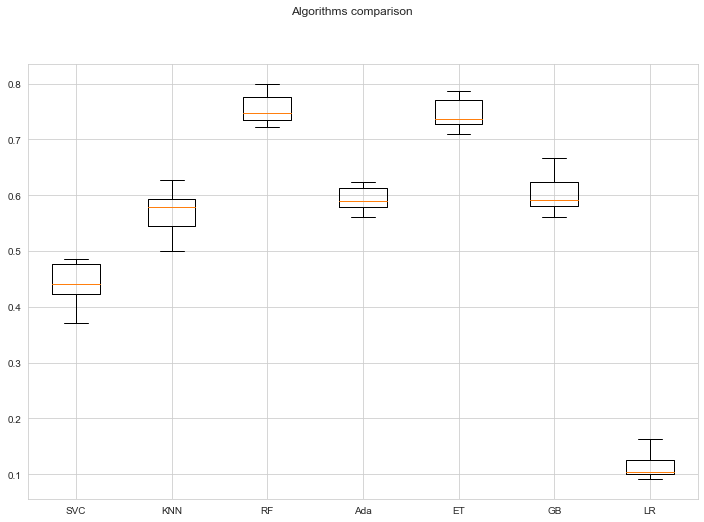

In [62]:
n_components = 5
pipelines = []
n_estimators = 200

#print(df.shape)
pipelines.append( ('SVC',
                   Pipeline([
                              ('sc', StandardScaler()),
#                               ('pca', PCA(n_components = n_components, random_state=seed ) ),
                             ('SVC', SVC(random_state=seed))]) ) )


pipelines.append(('KNN',
                  Pipeline([ 
                              ('sc', StandardScaler()),
#                             ('pca', PCA(n_components = n_components, random_state=seed ) ),
                            ('KNN', KNeighborsClassifier()) ])))

pipelines.append( ('RF',
                   Pipeline([
                              ('sc', StandardScaler()),
#                              ('pca', PCA(n_components = n_components, random_state=seed ) ), 
                             ('RF', RandomForestClassifier(random_state=seed, n_estimators=n_estimators)) ]) ))


pipelines.append( ('Ada',
                   Pipeline([ 
                              ('sc', StandardScaler()),
#                              ('pca', PCA(n_components = n_components, random_state=seed ) ), 
                    ('Ada', AdaBoostClassifier(random_state=seed,  n_estimators=n_estimators)) ]) ))

pipelines.append( ('ET',
                   Pipeline([
                              ('sc', StandardScaler()),
#                              ('pca', PCA(n_components = n_components, random_state=seed ) ), 
                             ('ET', ExtraTreesClassifier(random_state=seed, n_estimators=n_estimators)) ]) ))
pipelines.append( ('GB',
                   Pipeline([ 
                             ('sc', StandardScaler()),
#                             ('pca', PCA(n_components = n_components, random_state=seed ) ), 
                             ('GB', GradientBoostingClassifier(random_state=seed)) ]) ))

pipelines.append( ('LR',
                   Pipeline([
                              ('sc', StandardScaler()),
#                               ('pca', PCA(n_components = n_components, random_state=seed ) ), 
                             ('LR', LogisticRegression(random_state=seed)) ]) ))

results, names, times  = [], [] , []
num_folds = 10
scoring = 'f1'

for name, model in pipelines:
    start = time()
    kfold = StratifiedKFold(n_splits=num_folds, random_state=seed)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring = scoring,
                                n_jobs=-1) 
    t_elapsed = time() - start
    results.append(cv_results)
    names.append(name)
    times.append(t_elapsed)
    msg = "%s: %f (+/- %f) performed in %f seconds" % (name, 100*cv_results.mean(), 
                                                       100*cv_results.std(), t_elapsed)
    print(msg)


fig = plt.figure(figsize=(12,8))    
fig.suptitle("Algorithms comparison")
ax = fig.add_subplot(1,1,1)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()


**Observation:** The best performances are achieved by RF. However, RF also yields a wide distribution. It is worthy to continue our study by tuning RF. 

Logistic Regression performs badly. This might be due to the fact that the data is not normally distributed as these algorithms perform well when data that is normally distributed.

## 5. Algorithm tuning

### Tuning Random Forests

For random forest, we can tune the number of grown trees (n_estimators), the trees' depth (max_depth), the criterion of splitting (gini or entropy) and so on.... Let's start tuning these.

In [63]:
# Create a pipeline with a Random forest classifier
pipe_rfc = Pipeline([ 
                      ('scl', StandardScaler()), 
                    ('rfc', RandomForestClassifier(random_state=seed, n_jobs=-1) )])

# Set the grid parameters
param_grid_rfc =  [ {
    'rfc__n_estimators': [100, 200,300,400], # number of estimators
    #'rfc__criterion': ['gini', 'entropy'],   # Splitting criterion
    'rfc__max_features':[0.05 , 0.1], # maximum features used at each split
    'rfc__max_depth': [None, 5], # Max depth of the trees
    'rfc__min_samples_split': [0.005, 0.01], # mininal samples in leafs
    }]
# Use 10 fold CV
kfold = StratifiedKFold(n_splits=num_folds, random_state= seed)
grid_rfc = GridSearchCV(pipe_rfc, param_grid= param_grid_rfc, cv=kfold, scoring=scoring, verbose= 1, n_jobs=-1)

#Fit the pipeline
start = time()
grid_rfc = grid_rfc.fit(X_train, y_train)
end = time()

print("RFC grid search took %.3f seconds" %(end-start))

# Best score and best parameters
print('-------Best score----------')
print(grid_rfc.best_score_ * 100.0)
print('-------Best params----------')
print(grid_rfc.best_params_)

Fitting 10 folds for each of 32 candidates, totalling 320 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 320 out of 320 | elapsed:  2.2min finished


RFC grid search took 132.399 seconds
-------Best score----------
58.40277966467937
-------Best params----------
{'rfc__max_depth': None, 'rfc__max_features': 0.05, 'rfc__min_samples_split': 0.005, 'rfc__n_estimators': 200}


In [64]:
# Let's define some utility functions to plot the learning & validation curves

def plot_learning_curve(train_sizes, train_scores, test_scores, title, alpha=0.1):
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    plt.plot(train_sizes, train_mean, label='train score', color='blue', marker='o')
    plt.fill_between(train_sizes,train_mean + train_std,
                    train_mean - train_std, color='blue', alpha=alpha)
    plt.plot(train_sizes, test_mean, label='test score', color='red',marker='o')
    plt.fill_between(train_sizes,test_mean + test_std, test_mean - test_std , color='red', alpha=alpha)
    plt.title(title)
    plt.xlabel('Number of training points')
    plt.ylabel('Accuracy')
    plt.grid(ls='--')
    plt.legend(loc='best')
    plt.show()    
    
def plot_validation_curve(param_range, train_scores, test_scores, title, alpha=0.1):
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    plt.plot(param_range, train_mean, label='train score', color='blue', marker='o')
    plt.fill_between(param_range,train_mean + train_std,
                    train_mean - train_std, color='blue', alpha=alpha)
    plt.plot(param_range, test_mean, label='test score', color='red', marker='o')
    plt.fill_between(param_range,test_mean + test_std, test_mean - test_std , color='red', alpha=alpha)
    plt.title(title)
    plt.grid(ls='--')
    plt.xlabel('Parameter value')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.show()    

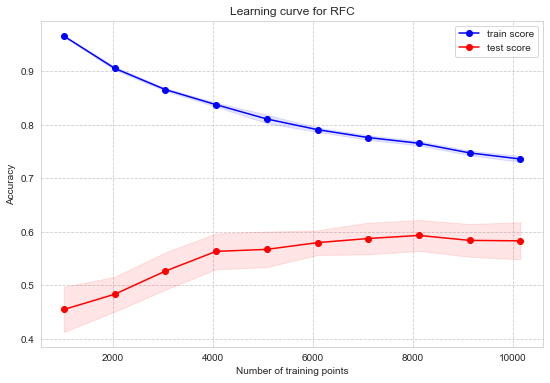

In [65]:
plt.figure(figsize=(9,6))

train_sizes, train_scores, test_scores = learning_curve(
              estimator= grid_rfc.best_estimator_ , X= X_train, y = y_train, 
                train_sizes=np.arange(0.1,1.1,0.1), cv= 10,  scoring='f1', n_jobs= - 1)

plot_learning_curve(train_sizes, train_scores, test_scores, title='Learning curve for RFC')

In [66]:
stand = StandardScaler()

Xt = stand.fit_transform(X_train)
Xv = stand.transform(X_test)

rnd = RandomForestClassifier(max_features=0.05, random_state=seed, n_estimators=200, max_depth= None,min_samples_split=0.005)

rnd.fit(Xt, y_train)

pred = rnd.predict(Xv)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      2048
           1       0.80      0.44      0.56       774

    accuracy                           0.82      2822
   macro avg       0.81      0.70      0.72      2822
weighted avg       0.81      0.82      0.80      2822



In [67]:
stand = StandardScaler()

Xt = stand.fit_transform(X_train)
Xv = stand.transform(test.drop('target', axis=1))
y = test['target']
#RandomForestClassifier
#ExtraTreesClassifier
rnd = RandomForestClassifier(max_features=0.05, random_state=seed, n_estimators=200, max_depth= None,min_samples_split=0.005)

rnd.fit(Xt, y_train)

pred = rnd.predict(Xv)

print(classification_report(y, pred))

              precision    recall  f1-score   support

           0       0.71      0.01      0.03       380
           1       0.27      0.99      0.42       140

    accuracy                           0.28       520
   macro avg       0.49      0.50      0.22       520
weighted avg       0.59      0.28      0.13       520



In [68]:
test.head()

,start_position,chou_fasman,emini,kolaskar_tongaonkar,parker,isoelectric_point,aromaticity,hydrophobicity,stability,target,length
0,1,0.887,0.040,1.056,-2.159,5.569763,0.116335,-0.061116,33.205116,0,16
1,1,0.869,0.047,1.056,-2.500,5.569763,0.116335,-0.061116,33.205116,0,14
2,2,0.621,0.042,1.148,-7.467,5.569763,0.116335,-0.061116,33.205116,0,8
3,6,1.021,0.230,1.049,0.927,5.569763,0.116335,-0.061116,33.205116,0,14
4,9,1.089,0.627,1.015,3.165,5.569763,0.116335,-0.061116,33.205116,0,16
